<a href="https://colab.research.google.com/github/ewst22ParkSY/ESAA11_PSY/blob/ESAA11_OB/ESAA_OB_WEEK12_2_transcript.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

필사 범위: 딥러닝 파이토치 교과서 ch5. 3 p.200~229

## 5.3 전이 학습

일반적으로 합성곱 신경망 기반의 딥러닝 모델을 제대로 훈련시키려면 많은 양의 데이터가 필요하지만 충분히 큰 데이터셋을 얻는 것은 쉽지 않음.

이런 현실적인 어려움을 해결한 것이 **전이 학습(transfer learning)**
- 이미지넷(ImageNet)처럼 아주 큰 데이터셋을 써서 훈련된 모델의 가중치를 가져와 우리가 해결하려는 과제에 맞게 보정해서 사용하는 것

사전 훈련된 모델(네트워크)
- 아주 큰 데이터셋을 사용하여 훈련된 모델
- 결과적으로 비교적 적은 수의 데이터를 가지고도 우리가 원하는 과제 해결 가능
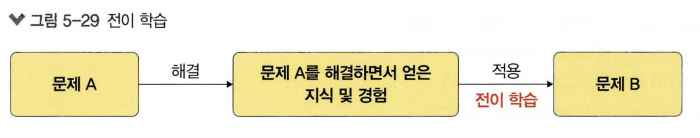


전이 학습 방법
- 특성 추출
미세 조정 기법

### 5.3.1 특성 추출 기법
특성 추출(Feature Extractor)
- ImageNet 데이터셋으로 사전 훈륜된 모델을 가져온 후 마지막에 완전연결층 부분만 새로 만듦.
- 학습할 때는 마지막 완전연결층(이미지의 카테고리를 결정하는 부분)만 학습하고 나머지 계층들은 학습되지 않도록 함.

특성 추출은 이미지 분류를 위해 두 부분으로 구성됨
- 합성곱층: 합성곱층과 풀링층으로 구성
- 데이터 분류기(완전연결층) : 추출된 특성을 입력받아 최종적으로 이미지에 대한 클래스를 분류하는 부분

사전 훈련된 네트워크의 합성곱층(가중치 고정)에 새로운 데이터를 통과시키고, 그 출력을 데이터 분류기에서 훈련시킴.

사용 가능한 이미지 분류 모델
- Xception
- Inception V3
- ResNet50
- VGG16
- VGG19
- MobileNet

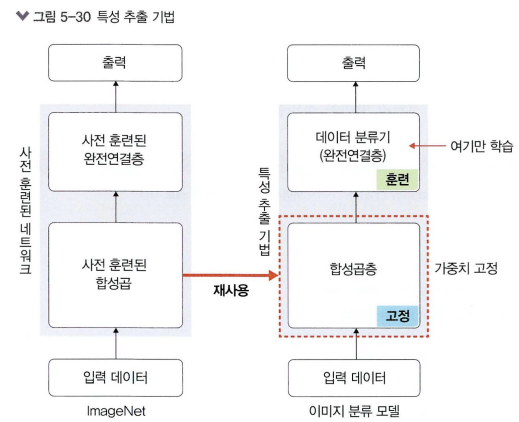

In [ ]:
pip install opencv-python

In [ ]:
#라이브러리 호출

import os
import time
import copy
import glob
import cv2 # 앞에서 설치한 OpenCV 라이브러리
import shutil

import torch
import torchvision # 컴퓨터 비전(computer vision) 용도의 패키지
import torchvision.transforms as transforms # 데이터 전처리를 위해 사용되는 패키지
import torchvision.models as models # 다양한 파이토치 네트워크를 사용할 수 있도록 도와주는 패키지
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [ ]:
# 1. 저장소 전체를 clone
!git clone https://github.com/gilbutITbook/080289.git

# 2. 작업 디렉토리를 해당 폴더로 이동
%cd 080289/chap05/data/catanddog/

# 3. 파일 목록 확인
!ls

fatal: destination path '080289' already exists and is not an empty directory.
/content/080289/chap05/data/catanddog
test  train


In [ ]:
data_path = '/content/080289/chap05/data/catanddog/train' # 이미지 데이터가 위치한 경로 지정

transform = transforms.Compose(
                [
                    transforms.Resize([256, 256]),
                    transforms.RandomResizedCrop(224),
                    transforms.RandomHorizontalFlip(),
                    transforms.ToTensor()
]) ## 1

train_dataset = torchvision.datasets.ImageFolder(
                data_path,
                transform=transform) ## 2

train_loader = torch.utils.data.DataLoader(
               train_dataset,
               batch_size=32,
               num_workers=8,
               shuffle=True
)

print(len(train_dataset))


385


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


1. ```torchvision.transform```은 이미지 데이터를 변환하여 모델(네트워크)의 입력으로 사용할 수 있게 변환해 줌. 사용되는 파라미터는 다음과 같음

```python
transform = transforms.Compose([transforms.Resize([256, 256]), ## a
            transforms.ResizedCrop(224), ## b
            transforms.RandomHorizontalFlip(), ## c
            transforms.ToTensor()]) ## d
```

  - a - Resize: 이미지의 크기를 조정. <br>
  - b - RandomResizedCrop: 이미지를 랜덤한 크기 및 비율로 자름(데이터 확장 용도로 사용됨.) <br>
  - c - RandomHorizontalFip: 이미지를 랜덤하게 수평으로 뒤집음 <br>
  - d - ToTensor: 이미지 데이터를 텐서로 변환

2. datasets.ImageFoler: 데이터로더가 데이터를 불러올 대상(혹은 경로)과 방법(transform)(혹은 전처리)을 정의하며, 사용하는 파라미터는 다음과 같음
```python
train_dataset = torchvision.datasets.ImageFolder(data_path, ## a
                                                 transform = transform ## b)
```
  - a 첫 번째 파라미터: 불러올 데이터가 위치한 경로
  - transform: 이미지 데이터에 대한 전처리

3. 데이터로더는 데이터를 불러오는 부분으로 앞에서 정의한 ImageFolder(train_dataset)을 데이터로더에 할당 > 한 번에 불러올 데이터양을 결정하는 batch_size를 지정함. > 데이터를무작위로 섞을(shuffle) 것인지도 설정<br>
데이터로더에 사용하는 파라미터
```python
train_loader = torch.utils.data.DataLoader(train_dataset, ## a
                                           batch_size = 32, ## b
                                           num_workers = 8, ## c
                                           shuffle = True) ## d
```
- a 첫 번째 파라미터: 데이터셋을 지정
- b batch_size: 한 번에 불러올 데이터양을 결정하는 배치 크기를 설정
- c num_workers: 데이터를 불러올 때 하위 프로세스를 몇 개 사용할지 설정 > 너무 많은 하위 프로세스를 설정하게 되면 오류가 발생하거나 메모리 부족 현상이 발생할 수 있음.
- d shuffle: 데이터를 무작위로 섞을지 지정.

RandomResizedCrop 자세히 알아보기<br>

````python
!pip install mxnet

import mxnet as mx
from mxnet.gluon.data.vision import transforms
import matplotlib.pyplot as plt # Import matplotlib for plotting

example_image = mx.image.imread('/content/catanddog/train/cat.jpg') # 예제를 진행할 이미지 불러오기
plt.imshow(example_image.asnumpy()) # 불러온 이미지 출력

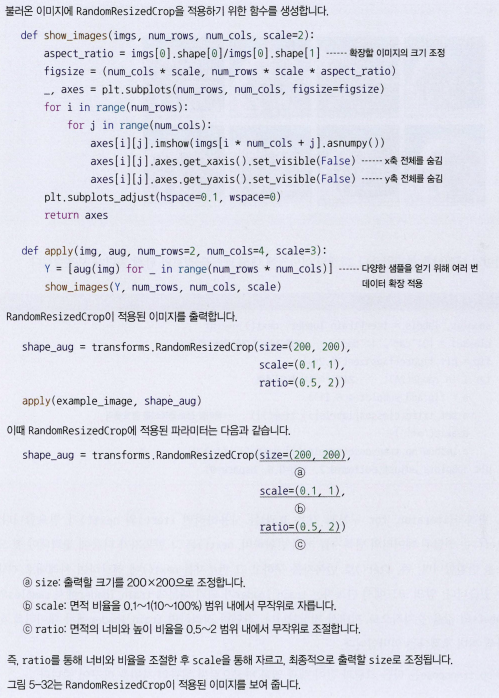

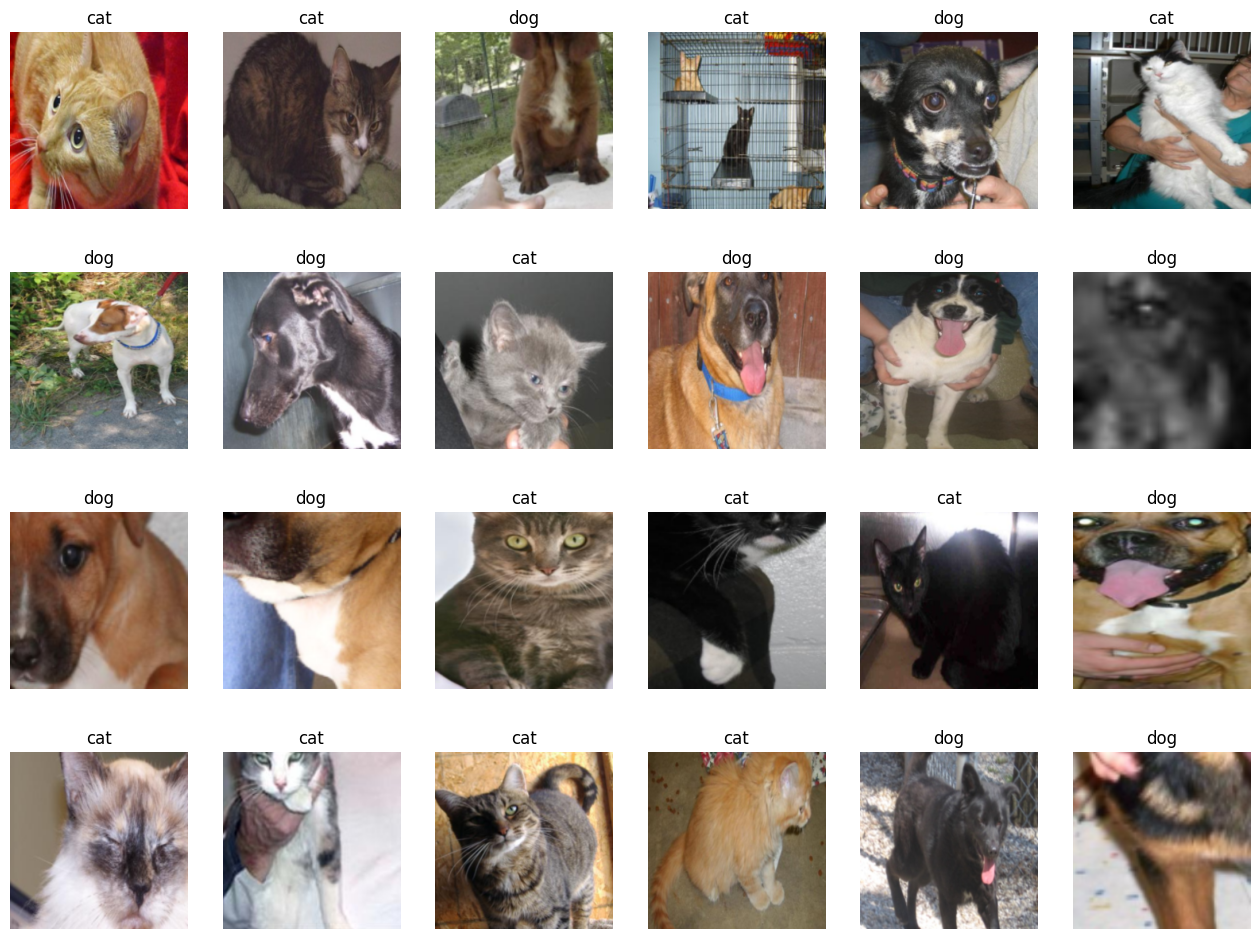

In [ ]:
# 학습에 사용될 이미지 출력
import numpy as np

samples, labels = next(iter(train_loader))## 1
classes = {0:'cat', 1:'dog'} # 개와 고양이에 대한 클래스로 구성
fig = plt.figure(figsize=(16, 24))
for i in range(24): # 24 개의 이미지 데이터 출력
    a = fig.add_subplot(4, 6, i+1)
    a.set_title(classes[labels[i].item()]) # 레이블 정보(클래스)를 함께 출력
    a.axis('off')
    a.imshow(np.transpose(samples[i].numpy(), (1, 2, 0))) ## 2
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

1. 반복자(iterator, for 구문과 같은 효과)를 사용하려면 iter()와 next()가 필요.
  - iter(): 전달된 데이터의 반복자를 꺼내 반환
  - next(): 그 반복자가 다음에 출력해야 할 요소를 반환

  iter()로 반복자를 구하고, 그 반복자를 next()에 전달하여 차례대로 꺼낼 수 있음.

  코드의미: train_loader에서 samples와 labels의 값을 순차적으로 꺼내서 저장.

2. np.transpose: 행과 열을 바꿈으로써 행렬의 차원을 바꾸어 줌.



In [ ]:
# 사전 훈련된 모델 내려받기
resnet18 = models.resnet18(pretrained=True) # pretrained = True는 사전 학습된 가중치를 사용하겠다는 의미

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 111MB/s]


In [ ]:
# 사전 훈련된 모델의 파라미터 학습 유무 지정
def set_parameter_requires_grad(model, feature_extracting=True):
    if feature_extracting:
       for param in model.parameters():
           param.requires_grad = False  ## 1

set_parameter_requires_grad(resnet18)

1. 역전파 중 파라미터들에 대한 변화를 계산할 필요가 없음을 나타냄.
> 모델의 일부를 고정하고 나머지를 학습하고자 할 때 requires_grad = False로 설정. (모델의 일부는 합성곱층(convolutional layer)과 풀링(pooling)층을 의미)



In [ ]:
# ResNet18에 완전연결층 추가
resnet18.fc = nn.Linear(512, 2) # 2는 클래스가 두 개라는 의미

In [ ]:
# 모델의 파라미터 값 확인
for name, param in resnet18.named_parameters():
    if param.requires_grad:
       print(name, param.data)

fc.weight tensor([[ 0.0246,  0.0294,  0.0174,  ...,  0.0372,  0.0281,  0.0202],
        [-0.0235,  0.0314, -0.0249,  ...,  0.0271, -0.0153, -0.0095]])
fc.bias tensor([0.0188, 0.0061])


In [ ]:
# 모델 객체 생성 및 손실 함수 정의
model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.fc = torch.nn.Linear(512, 2)
for param in model.fc.parameters(): # 완전 연결층은 학습
    param.requires_grad = True

optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss() # 손실 함수 정의
print(model)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs = 13, is_train=True):
    since = time.time() # 컴퓨터의 현재 시각을 구하는 함수
    acc_history = []
    loss_history = []
    best_acc = 0.0

    for epoch in range(num_epochs) : # 에포크만큼 반복
        print('Epoch {}/{}'.format(epoch, num_epochs-1))
        print('-' * 10)

        running_loss = 0.0
        running_corrects = 0.0

        for inputs, labels in dataloaders : # 데이터로더에 전달된 데이터만큼 반복
            inputs = inputs.to(device)
            labels = labels.to(device)

            model.to(device)
            optimizer.zero_grad() # 기울기를 0으로 설정
            outputs = model(inputs) # 순전파 학습
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            loss.backward() # 역전파 학습
            optimizer.step()

            running_loss += loss.item() * inputs.size(0) # 출력 결과와 레이블의 오차를 계산한 결과를 누적하여 저장
            running_corrects += torch.sum(preds == labels.data) # 출력 결과와 레이블이 동일한지 확인한 결과를 누적하여 저장

        epoch_loss = running_loss / len(dataloaders.dataset) # 평균 오차 계산
        epoch_acc = running_corrects.double() / len(dataloaders.dataset) # 평균 정확도 계산

        print('Loss: {:.4f} Acc {:.4f}'.format(epoch_loss, epoch_acc) )

        if epoch_acc > best_acc :
            best_acc = epoch_acc

        acc_history.append(epoch_acc.item())
        loss_history.append(epoch_loss)
        torch.save(model.state_dict(), os.path.join('/content/080289/chap05/data/catanddog',
                                                    '{0:0=2d}.pth'.format(epoch))) # 모델 재사용 위해 저장
        print()

    time_elapsed = time.time() - since # 실행시간을 계산
    print('Training complete in {:.0f}m {:.0f}s'. format(time_elapsed // 60, time_elapsed % 60))
    print('Best Acc:{:4f}'.format(best_acc))
    return acc_history, loss_history # 모델 정확도와 오차를 반환

In [ ]:
# 파라미터 학습 결과를 옵티마이저에 전달
params_to_update = []
for name, param in resnet18.named_parameters():
    if param.requires_grad == True:
      params_to_update.append(param) # 파라미터 학습 결과를 저장
      print("\t", name)

optimizer = optim.Adam(params_to_update) # 학습 결과를 옵티마이저에 저장

	 fc.weight
	 fc.bias


In [ ]:
# 모델 학습

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss() # 손실 함수 지정
train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion,
                                             optimizer, device)

Epoch 0/12
----------


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Loss: 0.1585 Acc 0.9325

Epoch 1/12
----------
Loss: 0.1731 Acc 0.9351

Epoch 2/12
----------
Loss: 0.1935 Acc 0.9325

Epoch 3/12
----------
Loss: 0.1652 Acc 0.9273

Epoch 4/12
----------


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Loss: 0.1390 Acc 0.9403

Epoch 5/12
----------
Loss: 0.1339 Acc 0.9429

Epoch 6/12
----------
Loss: 0.1346 Acc 0.9558

Epoch 7/12
----------
Loss: 0.1347 Acc 0.9429

Epoch 8/12
----------
Loss: 0.1260 Acc 0.9584

Epoch 9/12
----------
Loss: 0.1230 Acc 0.9506

Epoch 10/12
----------
Loss: 0.1410 Acc 0.9481

Epoch 11/12
----------
Loss: 0.1242 Acc 0.9558

Epoch 12/12
----------
Loss: 0.1178 Acc 0.9662

Training complete in 9m 52s
Best Acc:0.966234


In [ ]:
# 테스트 데이터 호출 및 전처리

test_path = '/content/080289/chap05/data/catanddog/test'

transform = transforms.Compose(
            [
                transforms.Resize(224),
                transforms.CenterCrop(224),
                transforms.ToTensor(),
])
test_dataset = torchvision.datasets.ImageFolder(
    root = test_path,
    transform = transform
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size = 32,
    num_workers=1,
    shuffle=True
)

print(len(test_dataset))

98


In [ ]:
def eval_model(model, dataloaders, device):
    since = time.time()
    acc_history = []
    best_acc = 0.0

    saved_models = glob.glob('/content/080289/chap05/data/catanddog/*.pth')
    saved_models.sort()
    print('saved_model', saved_models)

    for model_path in saved_models:
        print('Loading model', model_path)

        model.load_state_dict(torch.load(model_path))
        model.eval()
        model.to(device)
        running_corrects = 0

        for inputs, labels in dataloaders:
            inputs = inputs.to(device)
            labels = labels.to(device)

            with torch.no_grad():
                outputs = model(inputs)

            _, preds = torch.max(outputs.data, 1)

            # 이 두 줄은 사실 torch.max 이후에 의미가 없습니다. softmax 대신 sigmoid를 쓰는 경우만 필요함
            # preds[preds >= 0.5] = 1
            # preds[preds < 0.5] = 0

            running_corrects += preds.eq(labels).sum().item()

        epoch_acc = running_corrects / len(dataloaders.dataset)
        print('Acc: {:.4f}'.format(epoch_acc))

        if epoch_acc > best_acc:
            best_acc = epoch_acc
        acc_history.append(epoch_acc)  # 매 모델마다 기록

        time_elapsed = time.time() - since
        print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60,
                                                              time_elapsed % 60))
        print('Best Acc so far: {:.4f}'.format(best_acc))

    return acc_history

1. glob은 현재 디렉터리에서 원하는 파일들만 추출하여 가져올 때 사용
2. torch.max는 주어진 텐서 배열의 최댓값이 들어 있는 index를 반환하는 함수
3. preds.eq(labels)는 preds 배열과 labels가 일치하는지 검사하는 용도로 사용. 뒤에 있는 .sum()은 모델의 예측 결과와 정답(레이블)이 일치하는 것들의 개수 합을 숫자로 출

In [ ]:
val_acc_hist = eval_model(resnet18, test_loader, device)

saved_model ['/content/080289/chap05/data/catanddog/00.pth', '/content/080289/chap05/data/catanddog/01.pth', '/content/080289/chap05/data/catanddog/02.pth', '/content/080289/chap05/data/catanddog/03.pth', '/content/080289/chap05/data/catanddog/04.pth', '/content/080289/chap05/data/catanddog/05.pth', '/content/080289/chap05/data/catanddog/06.pth', '/content/080289/chap05/data/catanddog/07.pth', '/content/080289/chap05/data/catanddog/08.pth', '/content/080289/chap05/data/catanddog/09.pth', '/content/080289/chap05/data/catanddog/10.pth', '/content/080289/chap05/data/catanddog/11.pth', '/content/080289/chap05/data/catanddog/12.pth']
Loading model /content/080289/chap05/data/catanddog/00.pth
Acc: 0.7755
Validation complete in 0m 10s
Best Acc so far: 0.7755
Loading model /content/080289/chap05/data/catanddog/01.pth
Acc: 0.8980
Validation complete in 0m 20s
Best Acc so far: 0.8980
Loading model /content/080289/chap05/data/catanddog/02.pth
Acc: 0.9388
Validation complete in 0m 29s
Best Acc so 

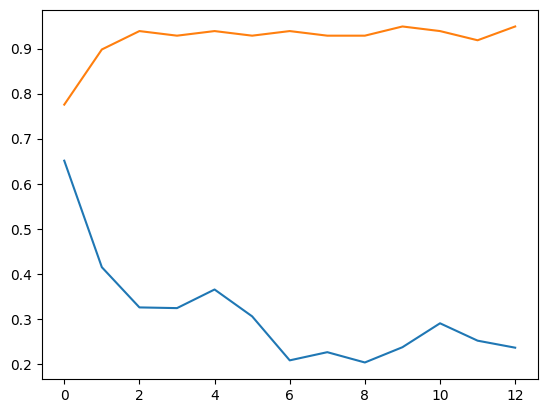

In [ ]:
# 훈련과 테스트 데이터의 정확도를 그래프로 확인
plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

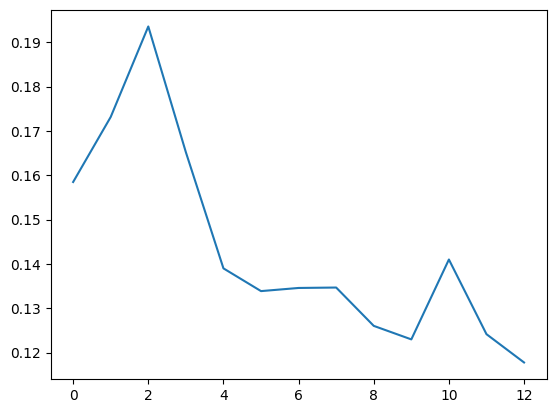

In [ ]:
plt.plot(train_loss_hist)
plt.show()

In [ ]:
# 예측 이미지 출력을 위한 전처리 함수
def im_convert(tensor) :
    image = tensor.clone().detach().numpy() ## 1
    image = image.transpose(1,2,0)
    image = image * (np.array((0.5, 0.5, 0.5)) + np.array((0.5, 0.5, 0.5)))
    image = image.clip(0,1) ## 2
    return image

1. tensor.clone()은 기존 텐서의 내용을 복사한 텐서를 생성하겠다는 의미, detach()는 기존 텐서에서 기울기가 전파되지 않는 텐서

tensor.clon(), tensor.detach(), tensor.clone().detach() 비교 표 <br>
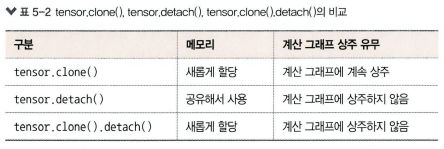

2. clip(): 입력 값이 주어진 범위를 벗어날 때 입력 값을 특정 범위로 제한시키기 위해 사용.

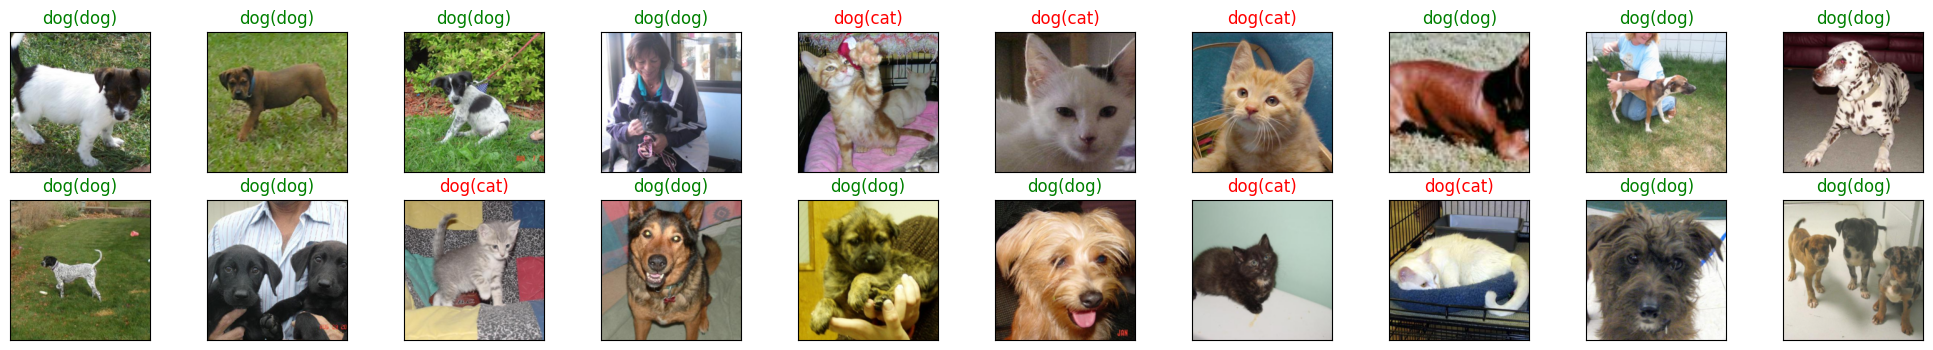

<Figure size 640x480 with 0 Axes>

In [ ]:
# 개와 고양이 예측 결과 출력

classes = {0: 'cat', 1: 'dog'} # 개와 고양이 두 개에 대한 레이블

dataiter = iter(test_loader) # 테스트 데이터셋을 가져오기
images, labels = next(dataiter) # 테스트 데이터셋에서 이미지와 레이블을 분리하여 가져옴
output = model(images)
_, preds = torch.max(output, 1)

fig = plt.figure(figsize=(25,4))
for idx in np.arange(20) :
    ax = fig.add_subplot(2, 10, idx+1, xticks = [], yticks = []) # 1
    plt.imshow(im_convert(images[idx]))
    a.set_title(classes[labels[i].item()])
    ax.set_title("{}({})".format(str(classes[preds[idx].item()]), str(classes[labels[idx].item()])),
                 color=('green' if preds[idx]==labels[idx] else 'red')) # 2
plt.show()
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0 ) # 3


1. add_subplot: 한 화면에 여러 개의 이미지를 담기 위해 사용.
> - 첫 번째 파라미터: 행의 수
> - 두 번째 파라미터: 열의 수
> - 세 번째 파라미터: 인덱스
> - 네 번째 파라미터: 틱(tick) 삭제

2. classes[preds[indx].item()]: preds[idx].item() 같이 classes로 정의된 '0'과 '1' 중 어떤 값을 갖는지 판별하겠다는 의미

3. Figure 안에서 서브플롯의 위치를 조정할 때 사용.

### 5.3.2 미세 조정 기법

특성 추출 기법에서 더 나아가 사전 훈련된 모델과 합성곱층, 데이터의 분류기 가중치를 업데이터하여 훈련시키는 방법
- 목표 특성을 잘 추출헀다는 전제 하에 좋은 성능을 낼 수 있음. 특성이 잘못 추출되었을 경우 미세 조정 기법으로 새로운 이미지 데이터를 사용하여 네트워크의 가중치를 업데이트해서 특성을 다시 추출할 수 있음.
> 사전 학습된 모델을 목적에 맞게 재학습시키거나 학습된 가중치 일부를 재학습시키는 것

- 사전 훈련된 네트워크를 미세 조정하여 분석하려는 데이터셋에 잘 맞도록 모델의 파라미터를 조정하는 기법.

미세 조정 기법의 전략
- 데이터셋이 크고 사전 훈련된 모델과 유사성이 작을 경우: 모델 전체를 재학습.
- 데이터셋이 크고 사전 훈련된 모델과 유사성이 클 경우: 합성곱층의 뒷부분(완전연결층과 가까운 부분)과 데이터 분류기를 학습.
- 데이터셋이 작고 사전 훈련된 모델과 유사성이 작을 경우: 학성곱층의 일부분과 데이터 분류기를 학습
- 데이터셋이 작고 사전 훈련된 모델과 유사성이 클 경우: 데이터 분류기만 학습

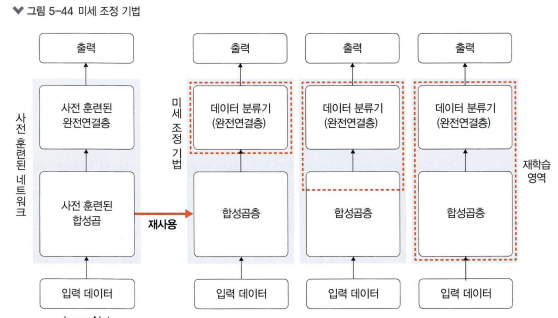